In [69]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow import keras
from copy import copy, deepcopy
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical

In [70]:
# Replace __FILL_ME__ with your information

# Data preparation and prepcrossing

In [71]:
# load data
(data_train, label_train), (data_test, label_test) = mnist.load_data()

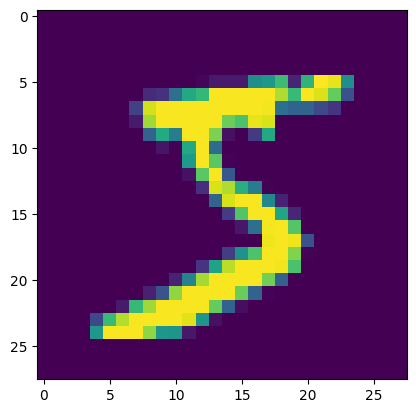

In [72]:
# display one test figure
test_fig = data_train[0]
plt.imshow(test_fig)

In [73]:
# normalize the data into the range of 0-1
data_train = data_train/data_train.max()
data_test = data_test/data_test.max()

Label = 0


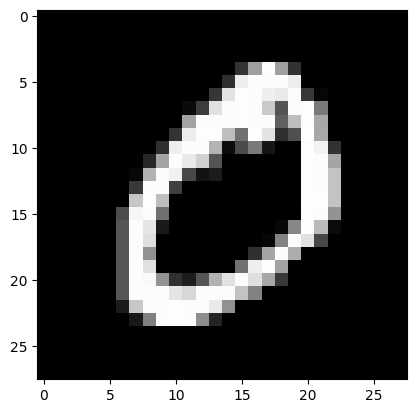

Label = 1


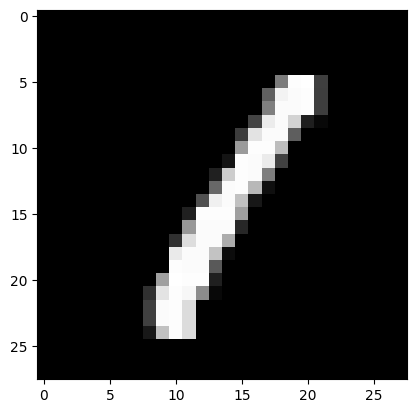

Label = 2


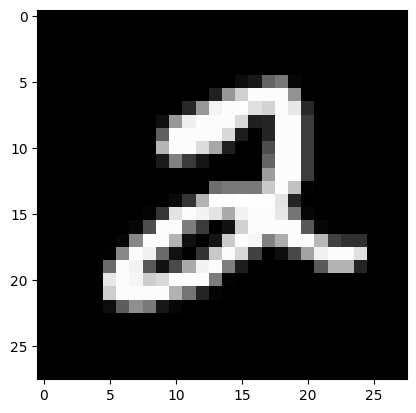

Label = 3


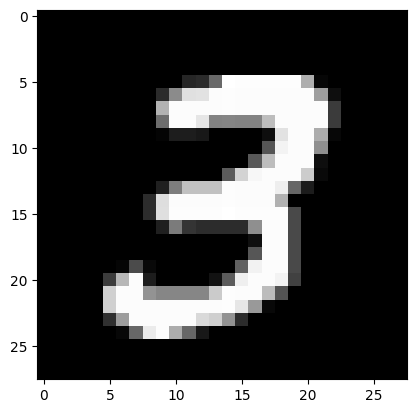

Label = 4


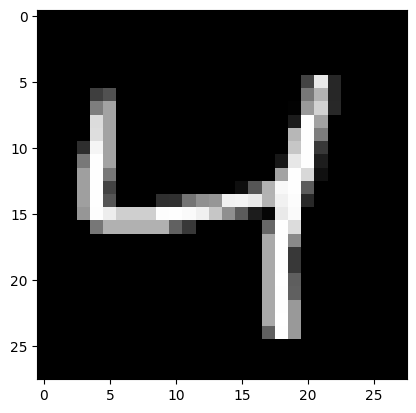

Label = 5


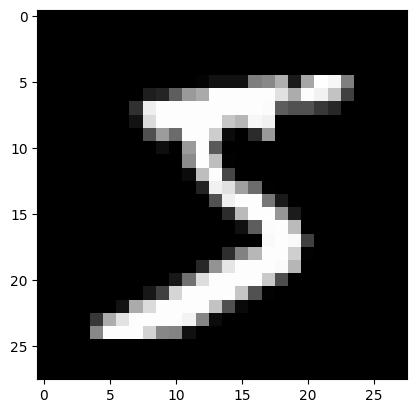

Label = 6


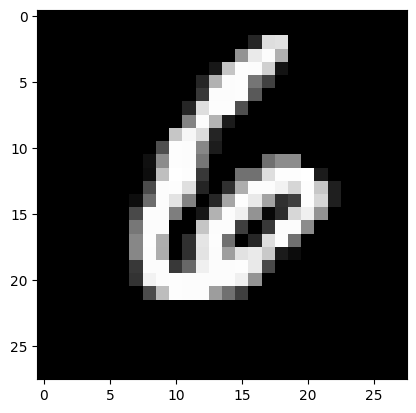

Label = 7


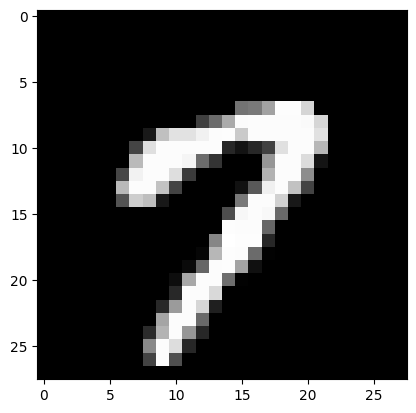

Label = 8


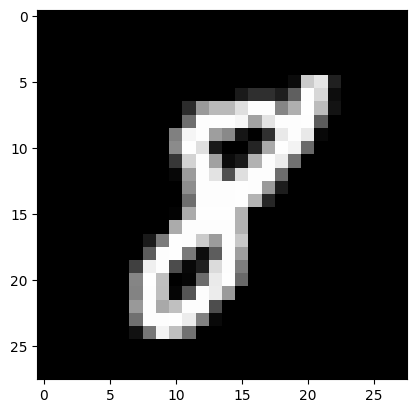

Label = 9


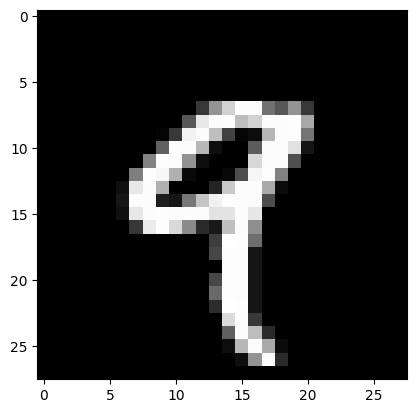

In [74]:
# display fig for each class
for i in range(10):
    for img_idx in range(10000):
        if int(label_train[img_idx]) == i:
            print('Label =', i)
            plt.imshow(data_train[img_idx], cmap = 'gray')
            plt.show()
            break
    

In [75]:
# 32 Floating Point data type is used
import sys
mem_fig = sys.getsizeof(data_train[0])
print('The required memory useage for each figure is: {} kb' .format(mem_fig) )

The required memory useage for each figure is: 128 kb


# Construct the MLP

In [76]:
# Considerations: number of layers, number of neurons in each layer, activation function

In [77]:
# Build up the MLP
# later you can change the number of neurons and layers

input_layer = Input(shape=data_train[0].shape)
input_layer_f = Flatten()(input_layer)

hidden_layer_1     = Dense(5, name='dense_1')(input_layer_f)
hidden_layer_1_act = Activation("relu", name="act_1")(hidden_layer_1)

hidden_layer_2     = Dense(8, name='dense_2')(hidden_layer_1_act)
hidden_layer_2_act = Activation("relu", name="act_2")(hidden_layer_2)

hidden_layer_3     = Dense(8, name='dense_3')(hidden_layer_2_act)
hidden_layer_3_act = Activation("relu", name="act_3")(hidden_layer_3)

output_layer       = Dense(10, name='output_layer')(hidden_layer_3_act)
output_layer_act   = Activation("softmax", name="softmax")(output_layer)

model = Model(input_layer, output_layer_act)


In [78]:
parameter_by_layer = np.zeros([4])

# layer 1
parameter_by_layer[0] = sys.getsizeof(model.layers[2].get_weights()[:2])
# layer 2
parameter_by_layer[1] = sys.getsizeof(model.layers[4].get_weights()[:2])
# layer 3 
parameter_by_layer[2] = sys.getsizeof(model.layers[6].get_weights()[:2])
# layer 4
parameter_by_layer[3] = sys.getsizeof(model.layers[8].get_weights()[:2])

mem_model = parameter_by_layer.sum() * 8 / 1000
            
print('The total memory usage for weights and bias is {} Kb'.format(mem_model))

The total memory usage for weights and bias is 2.304 Kb


In [79]:
# check the parameter numbers
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         3,925 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,135 (16.15 KB)

 Trainable params: 4,135 (16.15 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [80]:
# compile model
# define optimizer to perform backpropagation, loss function to evaluate loss
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [81]:
# train model with 80% data for training and 20% for validation with specified number of epochs, a small number is recommended (10)
r = model.fit(data_train, label_train,  validation_split= 0.2, epochs=10)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6344 - loss: 1.1301 - val_accuracy: 0.8508 - val_loss: 0.5780
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8508 - loss: 0.5268 - val_accuracy: 0.8722 - val_loss: 0.4617
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8683 - loss: 0.4556 - val_accuracy: 0.8796 - val_loss: 0.4205
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8773 - loss: 0.4231 - val_accuracy: 0.8856 - val_loss: 0.4078
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8825 - loss: 0.4029 - val_accuracy: 0.8863 - val_loss: 0.3947
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8866 - loss: 0.3895 - val_accuracy: 0.8863 - val_loss: 0.3899
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8892 - loss: 0.3783 - val_accuracy: 0.8909 - val_loss: 0.3804
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8914 - loss: 0.3723 - 

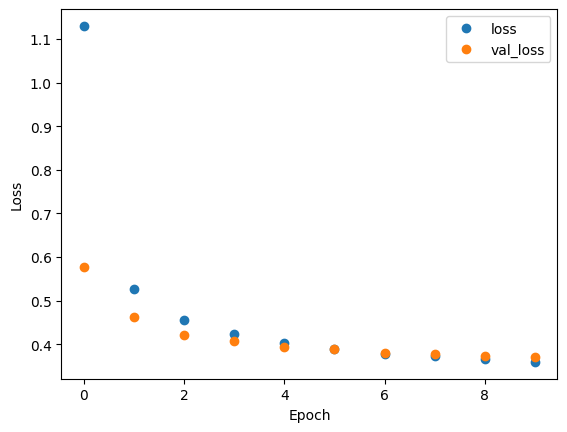

In [82]:
# plot loss
plt.plot(r.history['loss'],  'o', label='loss')
plt.plot(r.history['val_loss'],'o', label='val_loss',)
plt.ylabel('Loss')  # Set the label for the y-axis
plt.xlabel('Epoch')  # Set the label for the x-axis
plt.legend()
plt.show()

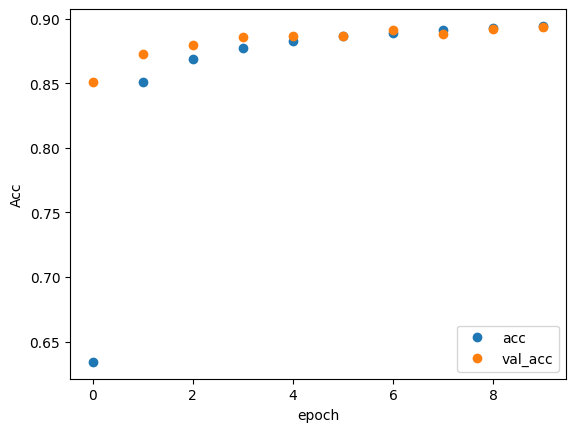

In [83]:
# Plot accuracy
plt.plot(r.history['accuracy'], 'o', label='acc')
plt.plot(r.history['val_accuracy'], 'o', label='val_acc')
plt.xlabel('epoch')
plt.ylabel('Acc')
plt.legend()
plt.show()


In [84]:
# Evaluate the model with test dataset - evaluate() returns loss and accuracy
print("Train Acc", model.evaluate(data_train, label_train)[1])
acc_floatingpoint =  model.evaluate(data_test, label_test)[1]
print("Test Acc:", acc_floatingpoint )

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8988 - loss: 0.3519
Train Acc 0.8988000154495239
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8930 - loss: 0.3763
Test Acc: 0.8930000066757202


In [85]:
# save model weights
model.save_weights("weights_floatingpoint.weights.h5")

Text(0, 0.5, 'Number')

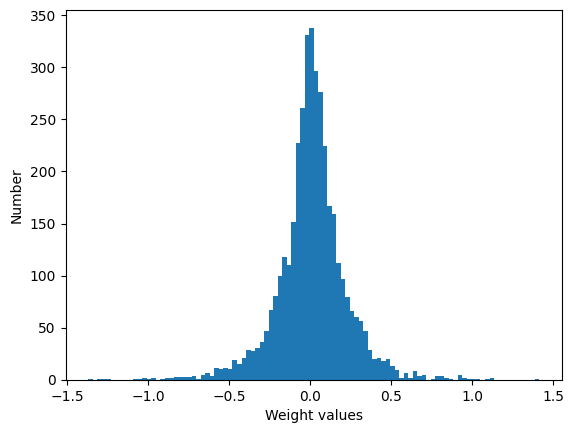

In [86]:
# observe the statistics of weights, for example in the first layer
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Number')

In [87]:
# What can you observe from the distribution of weights?

# Implement of the trained MLP with numpy

In [88]:
# implement the dense layer
def dense_layer(input_mat, input_vec, bias):
    # input_mat: (out_features, in_features)
    # input_vec: (in_features,)
    # bias: (out_features,)
    return input_mat @ input_vec + bias

In [89]:
# implement the ReLU activation function
def ReLU_layer(in_activations):
    return np.maximum(0, in_activations)

In [90]:
# implement the softmax activation function
def softmax_layer(in_activations):
    # in_activations: (n,)
    in_activations = in_activations - np.max(in_activations)
    exp_z = np.exp(in_activations)
    return exp_z / np.sum(exp_z)

In [91]:
# implement your own MLP, the weighs & biases should be extracted by model.get_weights()
# the softmax layer is not necessary to be implemented
input_example_np = np.ones([28*28])

W1, b1 = model.layers[2].get_weights()
W2, b2 = model.layers[4].get_weights()
W3, b3 = model.layers[6].get_weights()
W4, b4 = model.layers[8].get_weights()

output_1 = ReLU_layer(dense_layer(input_example_np, W1, b1))
output_2 = ReLU_layer(dense_layer(output_1, W2, b2))
output_3 = ReLU_layer(dense_layer(output_2, W3, b3))
output_4 = softmax_layer(dense_layer(output_3, W4, b4))

In [92]:
# Display your own results
output_4

array([1.47686977e-37, 1.80653389e-23, 1.53736493e-02, 4.82776531e-02,
       8.78988727e-13, 2.21763378e-05, 4.93343401e-11, 6.26408176e-26,
       9.36326521e-01, 2.50891729e-16])

In [93]:
# Compare with the reference
model.predict(tf.ones((1, 28, 28)), steps=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


array([[1.4768154e-37, 1.8065347e-23, 1.5373354e-02, 4.8279941e-02,
        8.7895283e-13, 2.2176688e-05, 4.9330231e-11, 6.2642039e-26,
        9.3632448e-01, 2.5090042e-16]], dtype=float32)

# MLP fixed point quantization

In [94]:
# Quantized the weights and evaluate the best combination of Integer and Fractional parts
# Compare the inference accuracy with TF model
# Estimate how much memory storage you can save with quantization 

In [95]:
# function to quantize weights with speficied bit width for integer and fractional part
def fixP_quantization(input_weight, int_BW, frac_BW):
    resolution_ = 2**(- frac_BW)
    range_ = 2**(int_BW + 1) # sign bit included
    
    weight = deepcopy(input_weight)
    
    input_weight_clipped = np.clip(weight, - range_ / 2, range_ / 2 - 1)
    input_weight_quantized = np.round(input_weight_clipped/resolution_) * resolution_
    
    return input_weight_quantized

In [96]:
# weight_quantization
BW_int = 9
BW_frac = 6

In [97]:
weight_quantized = [deepcopy(w) for w in model.get_weights()]

In [98]:
for i in range(len(weight_quantized)):
    weight_quantized[i] = fixP_quantization(np.copy(weight_quantized[i]), BW_int, BW_frac)

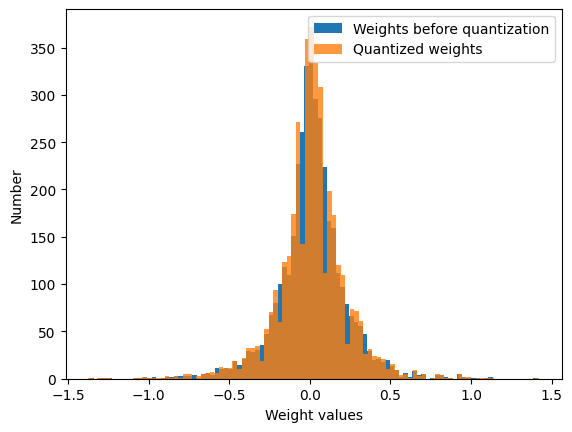

In [99]:
# plot the quantized weights in the first layer as example and compare with the floating point
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100, label = 'Weights before quantization', alpha = 1)
_ = plt.hist((weight_quantized[0].flatten()), bins = 100, label = 'Quantized weights', alpha = 0.8)
plt.xlabel('Weight values')
plt.ylabel('Number')

plt.legend()

In [100]:
# define the quantized model
model_quantized = Model(input_layer, output_layer_act)

In [101]:
# load weights and save 
model_quantized.set_weights(weight_quantized)
model_quantized.save_weights("weights_q_int{}_frac_{}.weights.h5" .format(BW_int, BW_frac))

# Evaluation of the quantization 

In [102]:
model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [103]:
# Evaluate the model - evaluate() returns loss and accuracy
print("Train Acc:", model_quantized.evaluate(data_train, label_train)[1])
acc_quantized = model_quantized.evaluate(data_test, label_test)[1]
print("Test Acc:", acc_quantized)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8983 - loss: 0.3520
Train Acc: 0.8982833623886108
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8917 - loss: 0.3763
Test Acc: 0.891700029373169


In [106]:
# Summary
# 32 FP numbers utilized in baseline model
saved_memory = mem_model / mem_model / 2
acc_drop = acc_floatingpoint - acc_quantized

In [107]:
print("Saved memory: {}% ".format(saved_memory*100))
print("Accuracy drop: {:.2f}%" .format(acc_drop*100))

Saved memory: 50.0% 
Accuracy drop: 0.13%
